<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/asgard_transport_open_data_to_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Åsgard Transport: open route data to a terrain-following NeqSim model

This executed notebook reconstructs a public Åsgard Transport route, develops an
approximate seabed profile and synthetic five-point cross-sections, exports a
documented `.C5P` candidate, and runs a segmented pressure/temperature model in
NeqSim.

It is a **screening and teaching workflow**, not an operator model, as-laid survey,
navigation product, integrity assessment, or design basis.


## Learning outcomes and evidence boundary

After running the notebook, you can:

1. retrieve the public SODIR pipeline geometry and order it Åsgard-to-Kårstø;
2. retain raw geodesic KP while scaling engineering KP to Gassco's published 720 km;
3. query EMODnet cross-track bathymetry and normalize five points per station;
4. export route CSV, GeoJSON, and a transparent synthetic `.C5P` candidate;
5. build a 144-segment, terrain-following `PipeBeggsAndBrills` model;
6. inspect pressure, temperature, terrain, mass balance, flow sensitivity, and mesh evidence.

Public observed context is separated from derived geometry and synthetic model inputs.
SODIR publishes FactMaps data under NLOD 2.0 and warns that positional accuracy varies;
Gassco reports 720 km and 42 inches. EMODnet is a regional bathymetry product, not an
as-laid pipeline survey.

Primary sources:

- [SODIR Åsgard Transport record](https://factpages.sodir.no/en/tuf/pageview/pipeline/all/307674)
- [SODIR open data and terms](https://www.sodir.no/en/about-us/open-data/)
- [SODIR FactMaps REST layer](https://factmaps.sodir.no/api/rest/services/DataService/Data/FeatureServer/6100)
- [Gassco transport map](https://gassco.eu/en/transport-map/)
- [EMODnet Bathymetry](https://emodnet.ec.europa.eu/en/bathymetry)
- [EMODnet Bathymetry REST service](https://rest.emodnet-bathymetry.eu/)

The default run uses an embedded snapshot collected from those services on 2026-08-10.
Set `REFRESH_OPEN_DATA = True` below to repeat the live queries in Colab.


In [1]:
import hashlib
import importlib.metadata
import importlib.util
import os
import subprocess
import sys
from pathlib import Path
from urllib.parse import unquote, urlparse

NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_COMMIT = "1dee5b51f6689d0b383e8d90fece9729132dd6e3"
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

required_packages = {
    "jpype": "JPype1>=1.5",
    "matplotlib": "matplotlib>=3.8",
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.2",
    "neqsim": "neqsim==3.17.0",
}
missing = [
    requirement
    for module, requirement in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing],
        check=True,
    )

source_root_env = os.environ.get("NEQSIM_SOURCE_ROOT")
source_jar_env = os.environ.get("NEQSIM_SOURCE_JAR")
PROJECT_ROOT = Path(
    source_root_env or "/content/neqsim-asgard-open-data"
).resolve()

if source_jar_env:
    checked_out_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True,
    ).strip()
    NEQSIM_JAR = Path(source_jar_env).resolve()
    build_mode = "prebuilt exact-source validation JAR"
else:
    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--filter=blob:none",
                "--no-checkout",
                NEQSIM_SOURCE_REPOSITORY,
                str(PROJECT_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        ["git", "fetch", "--depth=1", "origin", NEQSIM_SOURCE_COMMIT],
        cwd=PROJECT_ROOT,
        check=True,
    )
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_COMMIT],
        cwd=PROJECT_ROOT,
        check=True,
    )
    checked_out_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True,
    ).strip()
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=PROJECT_ROOT,
        check=True,
        timeout=1800,
    )
    jar_candidates = [
        path
        for path in (PROJECT_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            token in path.name
            for token in ["javadoc", "sources", "tests", "original"]
        )
    ]
    NEQSIM_JAR = max(jar_candidates, key=lambda path: path.stat().st_size)
    build_mode = "Maven package from exact Git commit"

assert checked_out_commit == NEQSIM_SOURCE_COMMIT
assert NEQSIM_JAR.is_file()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()

import jpype
import jpype.imports

jpype.addClassPath(str(NEQSIM_JAR))
if not jpype.isJVMStarted():
    jpype.startJVM(convertStrings=True)
JClass = jpype.JClass

probe_class = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
location_url = str(
    probe_class.class_.getProtectionDomain().getCodeSource().getLocation()
)
loaded_path = Path(unquote(urlparse(location_url).path)).resolve()
assert loaded_path == NEQSIM_JAR.resolve()

java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]
print("NeqSim source commit:", NEQSIM_SOURCE_COMMIT)
print("Build mode:", build_mode)
print("Runtime JAR SHA-256:", NEQSIM_JAR_SHA256)
print("Pipeline class location:", loaded_path)
print("Python:", sys.version.split()[0])
print("Java:", java_version)
print("neqsim Python bridge:", importlib.metadata.version("neqsim"))


NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
Build mode: prebuilt exact-source validation JAR
Runtime JAR SHA-256: 9fcff3aa74ff9dde9bab144c5a096bc7906b61b5d6c427dfc9c283fc62055b36
Pipeline class location: /tmp/neqsim-source-1dee5b51f668.jar
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21
neqsim Python bridge: 3.17.0


## Open-data reconstruction method

The public geometry is stored in the opposite direction, so the longest geometry part is
reversed. Great-circle distance gives a raw cumulative KP. Both measures are retained:

$$KP_{eng}=KP_{raw}\frac{720\ \mathrm{km}}{L_{raw}}$$

Stations are interpolated every 5 km in engineering KP. At each station, an EMODnet
`depth_profile` query spans 200 m normal to the route. Five samples at offsets
−100, −50, 0, +50, and +100 m form the normalized cross-section.

The functions below are the complete live retrieval path. The saved run uses the embedded
snapshot so the notebook remains reproducible when either public service is unavailable.


In [2]:
import json
import math
import time
import urllib.parse
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

SODIR_PIPELINE_ID = 307674
OFFICIAL_LENGTH_KM = 720.0
STATION_INTERVAL_KM = 5.0
CROSS_TRACK_OFFSETS_M = (-100.0, -50.0, 0.0, 50.0, 100.0)
EARTH_RADIUS_M = 6_371_008.8
SODIR_QUERY_URL = (
    "https://factmaps.sodir.no/api/rest/services/DataService/Data/"
    "FeatureServer/6100/query"
)
EMODNET_PROFILE_URL = (
    "https://rest.emodnet-bathymetry.eu/depth_profile"
)
USER_AGENT = "NeqSim-Colab-Asgard-Open-Data/1.0"
REFRESH_OPEN_DATA = False


def fetch_json(url, params, attempts=4):
    query = urllib.parse.urlencode(params)
    request = urllib.request.Request(
        f"{url}?{query}",
        headers={"User-Agent": USER_AGENT},
    )
    last_error = None
    for attempt in range(attempts):
        try:
            with urllib.request.urlopen(request, timeout=45) as response:
                return json.load(response)
        except Exception as error:
            last_error = error
            if attempt + 1 < attempts:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"Failed to fetch {url}") from last_error


def haversine_m(point_a, point_b):
    lon_a, lat_a = map(math.radians, point_a)
    lon_b, lat_b = map(math.radians, point_b)
    delta_lon = lon_b - lon_a
    delta_lat = lat_b - lat_a
    value = (
        math.sin(delta_lat / 2.0) ** 2
        + math.cos(lat_a)
        * math.cos(lat_b)
        * math.sin(delta_lon / 2.0) ** 2
    )
    return 2.0 * EARTH_RADIUS_M * math.asin(math.sqrt(value))


def bearing_deg(point_a, point_b):
    lon_a, lat_a = map(math.radians, point_a)
    lon_b, lat_b = map(math.radians, point_b)
    delta_lon = lon_b - lon_a
    east = math.sin(delta_lon) * math.cos(lat_b)
    north = (
        math.cos(lat_a) * math.sin(lat_b)
        - math.sin(lat_a) * math.cos(lat_b) * math.cos(delta_lon)
    )
    return (math.degrees(math.atan2(east, north)) + 360.0) % 360.0


def destination_point(point, bearing, distance_m):
    lon, lat = map(math.radians, point)
    angular_distance = distance_m / EARTH_RADIUS_M
    bearing_rad = math.radians(bearing)
    lat_out = math.asin(
        math.sin(lat) * math.cos(angular_distance)
        + math.cos(lat)
        * math.sin(angular_distance)
        * math.cos(bearing_rad)
    )
    lon_out = lon + math.atan2(
        math.sin(bearing_rad)
        * math.sin(angular_distance)
        * math.cos(lat),
        math.cos(angular_distance) - math.sin(lat) * math.sin(lat_out),
    )
    longitude = (math.degrees(lon_out) + 540.0) % 360.0 - 180.0
    return longitude, math.degrees(lat_out)


def wgs84_to_utm32(longitude_deg, latitude_deg):
    semi_major = 6_378_137.0
    flattening = 1.0 / 298.257223563
    scale = 0.9996
    eccentricity_sq = flattening * (2.0 - flattening)
    second_ecc_sq = eccentricity_sq / (1.0 - eccentricity_sq)
    latitude = math.radians(latitude_deg)
    longitude = math.radians(longitude_deg)
    central_meridian = math.radians(9.0)
    prime_vertical = semi_major / math.sqrt(
        1.0 - eccentricity_sq * math.sin(latitude) ** 2
    )
    tangent_sq = math.tan(latitude) ** 2
    c_term = second_ecc_sq * math.cos(latitude) ** 2
    a_term = math.cos(latitude) * (longitude - central_meridian)
    meridional_arc = semi_major * (
        (
            1.0
            - eccentricity_sq / 4.0
            - 3.0 * eccentricity_sq**2 / 64.0
            - 5.0 * eccentricity_sq**3 / 256.0
        )
        * latitude
        - (
            3.0 * eccentricity_sq / 8.0
            + 3.0 * eccentricity_sq**2 / 32.0
            + 45.0 * eccentricity_sq**3 / 1024.0
        )
        * math.sin(2.0 * latitude)
        + (
            15.0 * eccentricity_sq**2 / 256.0
            + 45.0 * eccentricity_sq**3 / 1024.0
        )
        * math.sin(4.0 * latitude)
        - 35.0 * eccentricity_sq**3 / 3072.0
        * math.sin(6.0 * latitude)
    )
    easting = 500_000.0 + scale * prime_vertical * (
        a_term
        + (1.0 - tangent_sq + c_term) * a_term**3 / 6.0
        + (
            5.0
            - 18.0 * tangent_sq
            + tangent_sq**2
            + 72.0 * c_term
            - 58.0 * second_ecc_sq
        )
        * a_term**5
        / 120.0
    )
    northing = scale * (
        meridional_arc
        + prime_vertical
        * math.tan(latitude)
        * (
            a_term**2 / 2.0
            + (
                5.0
                - tangent_sq
                + 9.0 * c_term
                + 4.0 * c_term**2
            )
            * a_term**4
            / 24.0
            + (
                61.0
                - 58.0 * tangent_sq
                + tangent_sq**2
                + 600.0 * c_term
                - 330.0 * second_ecc_sq
            )
            * a_term**6
            / 720.0
        )
    )
    return easting, northing


def cumulative_distances(points):
    distances = [0.0]
    for point_a, point_b in zip(points, points[1:]):
        distances.append(distances[-1] + haversine_m(point_a, point_b))
    return distances


def interpolate_route(points, cumulative_m, target_m):
    if target_m <= 0.0:
        return points[0]
    if target_m >= cumulative_m[-1]:
        return points[-1]
    upper = int(np.searchsorted(cumulative_m, target_m, side="right"))
    lower = upper - 1
    fraction = (
        (target_m - cumulative_m[lower])
        / (cumulative_m[upper] - cumulative_m[lower])
    )
    lon_a, lat_a = points[lower]
    lon_b, lat_b = points[upper]
    return (
        lon_a + fraction * (lon_b - lon_a),
        lat_a + fraction * (lat_b - lat_a),
    )


def retrieve_sodir_route():
    payload = fetch_json(
        SODIR_QUERY_URL,
        {
            "where": f"pplNpdidPipeline={SODIR_PIPELINE_ID}",
            "outFields": "*",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson",
        },
    )
    features = payload.get("features", [])
    if len(features) != 1:
        raise RuntimeError(f"Expected one route feature, got {len(features)}")
    feature = features[0]
    main_part = max(feature["geometry"]["coordinates"], key=len)
    points = [(float(lon), float(lat)) for lon, lat in reversed(main_part)]
    return points, feature["properties"]


def build_route_stations(points):
    raw_cumulative_m = cumulative_distances(points)
    raw_length_km = raw_cumulative_m[-1] / 1000.0
    kp_scale = OFFICIAL_LENGTH_KM / raw_length_km
    station_rows = []
    station_kps = np.arange(
        0.0,
        OFFICIAL_LENGTH_KM + STATION_INTERVAL_KM,
        STATION_INTERVAL_KM,
    )
    for station_index, engineering_kp_km in enumerate(station_kps):
        raw_target_m = engineering_kp_km * 1000.0 / kp_scale
        longitude, latitude = interpolate_route(
            points,
            raw_cumulative_m,
            raw_target_m,
        )
        easting, northing = wgs84_to_utm32(longitude, latitude)
        station_rows.append(
            {
                "station_index": station_index,
                "engineering_kp_km": engineering_kp_km,
                "raw_geodesic_kp_km": raw_target_m / 1000.0,
                "longitude_deg_wgs84": longitude,
                "latitude_deg_wgs84": latitude,
                "utm32_easting_m_wgs84": easting,
                "utm32_northing_m_wgs84": northing,
            }
        )
    stations = pd.DataFrame(station_rows)
    bearings = []
    for index in range(len(stations)):
        lower = max(0, index - 1)
        upper = min(len(stations) - 1, index + 1)
        point_a = (
            stations.loc[lower, "longitude_deg_wgs84"],
            stations.loc[lower, "latitude_deg_wgs84"],
        )
        point_b = (
            stations.loc[upper, "longitude_deg_wgs84"],
            stations.loc[upper, "latitude_deg_wgs84"],
        )
        bearings.append(bearing_deg(point_a, point_b))
    stations["route_bearing_deg"] = bearings
    return stations, raw_length_km, kp_scale


def sample_emodnet_station(station):
    center = (
        station["longitude_deg_wgs84"],
        station["latitude_deg_wgs84"],
    )
    bearing = station["route_bearing_deg"]
    left = destination_point(center, bearing - 90.0, 100.0)
    right = destination_point(center, bearing + 90.0, 100.0)
    line_wkt = (
        f"LINESTRING({left[0]:.9f} {left[1]:.9f},"
        f"{right[0]:.9f} {right[1]:.9f})"
    )
    depths = fetch_json(EMODNET_PROFILE_URL, {"geom": line_wkt})
    if not isinstance(depths, list) or len(depths) < 5:
        raise RuntimeError("EMODnet returned an unexpected depth profile")
    rows = []
    roles = [
        "left_outer",
        "left_inner",
        "centreline",
        "right_inner",
        "right_outer",
    ]
    for point_index, (offset_m, role) in enumerate(
        zip(CROSS_TRACK_OFFSETS_M, roles),
        start=1,
    ):
        fraction = (offset_m + 100.0) / 200.0
        depth_index = min(
            len(depths) - 1,
            round(fraction * (len(depths) - 1)),
        )
        longitude, latitude = destination_point(
            center,
            bearing + 90.0,
            offset_m,
        )
        easting, northing = wgs84_to_utm32(longitude, latitude)
        elevation = float(depths[depth_index])
        rows.append(
            {
                "engineering_kp_km": station["engineering_kp_km"],
                "point_index": point_index,
                "point_role": role,
                "offset_m": offset_m,
                "longitude_deg_wgs84": longitude,
                "latitude_deg_wgs84": latitude,
                "utm32_easting_m_wgs84": easting,
                "utm32_northing_m_wgs84": northing,
                "seabed_elevation_m_lat": elevation,
                "water_depth_m_lat": max(0.0, -elevation),
            }
        )
    return rows


def retrieve_emodnet_sections(stations, max_workers=8):
    section_rows = [None] * len(stations)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(
                sample_emodnet_station,
                row._asdict(),
            ): index
            for index, row in enumerate(stations.itertuples(index=False))
        }
        for future in as_completed(futures):
            section_rows[futures[future]] = future.result()
    flattened = [point for section in section_rows for point in section]
    return pd.DataFrame(flattened)


In [3]:
import base64
import gzip
from io import StringIO

SNAPSHOT_RETRIEVED_DATE = "2026-08-10"
SNAPSHOT_BUNDLE_SHA256 = "21340d05d45db607d2b0f3339ef6e575b31afacb6c4b46b6cfbf756764124a2c"
SNAPSHOT_GZIP_BASE64 = (
    "..."
    "xx//hy1U/+P/Bz9FztUyLQIA"
)

snapshot_raw = gzip.decompress(base64.b64decode(SNAPSHOT_GZIP_BASE64))
assert hashlib.sha256(snapshot_raw).hexdigest() == SNAPSHOT_BUNDLE_SHA256
snapshot = json.loads(snapshot_raw.decode("utf-8"))


def snapshot_frame(file_name, **kwargs):
    return pd.read_csv(StringIO(snapshot[file_name]), **kwargs)


vertex_df = snapshot_frame("asgard_transport_sodir_vertices.csv")
route_df = snapshot_frame(
    "asgard_transport_route_kp.csv",
    dtype={"station_index": "Int64"},
)
profile_df = snapshot_frame("asgard_transport_seabed_profile.csv")
cross_df = snapshot_frame(
    "asgard_transport_five_point_cross_sections.csv",
    dtype={"point_index": "Int64"},
)
metadata = json.loads(snapshot["asgard_transport_metadata.json"])
data_mode = f"embedded public-data snapshot from {SNAPSHOT_RETRIEVED_DATE}"

if REFRESH_OPEN_DATA:
    live_points, live_properties = retrieve_sodir_route()
    route_df, raw_length_km, kp_scale = build_route_stations(live_points)
    cross_df = retrieve_emodnet_sections(route_df)
    centerline = cross_df.loc[cross_df["point_index"] == 3].copy()
    grouped = cross_df.groupby("engineering_kp_km")
    profile_df = centerline[
        [
            "engineering_kp_km",
            "longitude_deg_wgs84",
            "latitude_deg_wgs84",
            "utm32_easting_m_wgs84",
            "utm32_northing_m_wgs84",
            "seabed_elevation_m_lat",
            "water_depth_m_lat",
        ]
    ].copy()
    profile_df["cross_section_min_elevation_m_lat"] = grouped[
        "seabed_elevation_m_lat"
    ].min().to_numpy()
    profile_df["cross_section_max_elevation_m_lat"] = grouped[
        "seabed_elevation_m_lat"
    ].max().to_numpy()
    profile_df["source"] = "EMODnet Bathymetry REST depth_profile"
    metadata["raw_public_geometry_length_km"] = raw_length_km
    metadata["engineering_kp_scale_factor"] = kp_scale
    metadata["sodir_reported_maximum_water_depth_m"] = live_properties[
        "pplWaterDepth"
    ]
    data_mode = "live SODIR and EMODnet refresh"

route_checks = {
    "data mode": data_mode,
    "SODIR vertices": len(vertex_df),
    "route stations": len(route_df),
    "five-point records": len(cross_df),
    "raw public length [km]": metadata[
        "raw_public_geometry_length_km"
    ],
    "engineering end KP [km]": route_df["engineering_kp_km"].iloc[-1],
    "KP scale factor": metadata["engineering_kp_scale_factor"],
    "deepest centreline [m below LAT]": profile_df[
        "water_depth_m_lat"
    ].max(),
}
display(pd.Series(route_checks, name="value").to_frame())
display(route_df.head(4).round(6))


,value
data mode,embedded public-data snapshot from 2026-08-10
SODIR vertices,148
route stations,145
five-point records,725
raw public length [km],688.87748
engineering end KP [km],720.0
KP scale factor,1.045179
deepest centreline [m below LAT],370.05


,station_index,engineering_kp_km,raw_geodesic_kp_km,longitude_deg_wgs84,latitude_deg_wgs84,utm32_easting_m_wgs84,utm32_northing_m_wgs84,route_bearing_deg
0,0,0.0,0.000000,6.797201,65.106399,396553.180388,7.222117e+06,178.977981
1,1,5.0,4.783871,6.798991,65.064097,396472.956109,7.217402e+06,183.152915
2,2,10.0,9.567743,6.786118,65.021434,395701.076821,7.212670e+06,187.729249
3,3,15.0,14.351614,6.771637,64.978852,394851.794116,7.207951e+06,188.138749


## Route, cumulative KP, and approximate terrain

The snapshot contains all 148 public SODIR vertices and 145 resampled stations.
The low-resolution route is generalized and cut near facilities; the positional data
must not be interpreted as an as-laid centerline. The depth envelope shows the range
across the five points at each station.


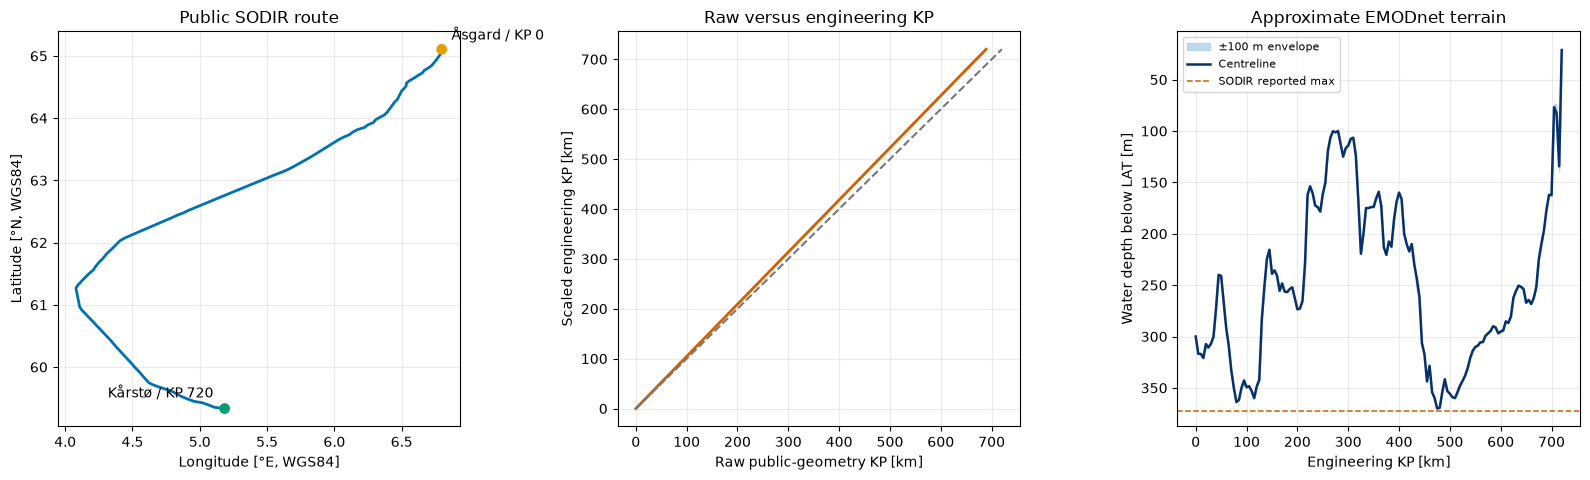

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.9))

axes[0].plot(
    route_df["longitude_deg_wgs84"],
    route_df["latitude_deg_wgs84"],
    color="#0072B2",
    linewidth=2.0,
)
axes[0].scatter(
    route_df.loc[[0, len(route_df) - 1], "longitude_deg_wgs84"],
    route_df.loc[[0, len(route_df) - 1], "latitude_deg_wgs84"],
    color=["#E69F00", "#009E73"],
    s=45,
    zorder=3,
)
axes[0].annotate(
    "Åsgard / KP 0",
    (
        route_df.loc[0, "longitude_deg_wgs84"],
        route_df.loc[0, "latitude_deg_wgs84"],
    ),
    xytext=(7, 7),
    textcoords="offset points",
)
axes[0].annotate(
    "Kårstø / KP 720",
    (
        route_df.loc[len(route_df) - 1, "longitude_deg_wgs84"],
        route_df.loc[len(route_df) - 1, "latitude_deg_wgs84"],
    ),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
)
axes[0].set_title("Public SODIR route")
axes[0].set_xlabel("Longitude [°E, WGS84]")
axes[0].set_ylabel("Latitude [°N, WGS84]")
axes[0].grid(alpha=0.25)

axes[1].plot(
    vertex_df["raw_geodesic_kp_km"],
    vertex_df["engineering_kp_km_scaled"],
    color="#D55E00",
    linewidth=2.0,
)
axes[1].plot([0, 720], [0, 720], "--", color="#777777")
axes[1].set_title("Raw versus engineering KP")
axes[1].set_xlabel("Raw public-geometry KP [km]")
axes[1].set_ylabel("Scaled engineering KP [km]")
axes[1].grid(alpha=0.25)

kp_values = profile_df["engineering_kp_km"]
center_depth = profile_df["water_depth_m_lat"]
deep_depth = np.maximum(
    0.0,
    -profile_df["cross_section_min_elevation_m_lat"],
)
shallow_depth = np.maximum(
    0.0,
    -profile_df["cross_section_max_elevation_m_lat"],
)
axes[2].fill_between(
    kp_values,
    shallow_depth,
    deep_depth,
    color="#9ECAE1",
    alpha=0.65,
    label="±100 m envelope",
)
axes[2].plot(
    kp_values,
    center_depth,
    color="#08306B",
    linewidth=1.8,
    label="Centreline",
)
axes[2].axhline(
    metadata["sodir_reported_maximum_water_depth_m"],
    color="#D55E00",
    linestyle="--",
    linewidth=1.1,
    label="SODIR reported max",
)
axes[2].invert_yaxis()
axes[2].set_title("Approximate EMODnet terrain")
axes[2].set_xlabel("Engineering KP [km]")
axes[2].set_ylabel("Water depth below LAT [m]")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

figure.tight_layout()
plt.show()


## Five-point cross-sections and synthetic `.C5P`

The normalized CSV is authoritative. The `.C5P` text is a transparent teaching schema,
not a surveyed or importer-certified SITRAS/NaviModel file. Each record contains KP,
bearing, and five UTM32 `(E, N, Z)` tuples. Elevation is relative to LAT and is negative
below LAT.

The nullable pandas `Int64` type is used for `survey_year`. That is the safe fix when a
manual-import header can contain blanks; direct `astype(int)` raises
`IntCastingNaNError` on missing values.


In [5]:
from pathlib import Path

OUTPUT_DIR = Path(
    os.environ.get("ASGARD_OUTPUT_DIR", "/content/asgard_transport_outputs")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def make_synthetic_c5p(route, sections, survey_year=2026):
    header = pd.DataFrame(
        {
            "asset": ["Åsgard Transport"],
            "survey_year": [survey_year],
            "crs": ["EPSG:32632"],
            "vertical_datum": ["LAT"],
        }
    )
    header["survey_year"] = pd.to_numeric(
        header["survey_year"],
        errors="coerce",
    ).astype("Int64")
    lines = [
        "# SYNTHETIC_C5P_ASCII_V1",
        "# Asset: Aasgard Transport; SODIR pipeline ID: 307674",
        f"# Survey year: {int(header.loc[0, 'survey_year'])}",
        "# CRS: WGS84 / UTM zone 32N (EPSG:32632); vertical datum: LAT",
        "# NOT a surveyed or importer-verified proprietary C5P deliverable.",
        (
            "# record,kp_km,bearing_deg,"
            "p1_e_m,p1_n_m,p1_z_m,p2_e_m,p2_n_m,p2_z_m,"
            "p3_e_m,p3_n_m,p3_z_m,p4_e_m,p4_n_m,p4_z_m,"
            "p5_e_m,p5_n_m,p5_z_m"
        ),
    ]
    for station in route.itertuples(index=False):
        station_points = sections.loc[
            np.isclose(
                sections["engineering_kp_km"],
                station.engineering_kp_km,
            )
        ].sort_values("point_index")
        values = [
            "C5P1",
            f"{station.engineering_kp_km:.3f}",
            f"{station.route_bearing_deg:.3f}",
        ]
        for point in station_points.itertuples(index=False):
            values.extend(
                [
                    f"{point.utm32_easting_m_wgs84:.3f}",
                    f"{point.utm32_northing_m_wgs84:.3f}",
                    f"{point.seabed_elevation_m_lat:.3f}",
                ]
            )
        lines.append(",".join(values))
    return header, "\n".join(lines) + "\n"


c5p_header, c5p_text = make_synthetic_c5p(route_df, cross_df)
c5p_path = OUTPUT_DIR / "AT260001.C5P"
c5p_path.write_text(c5p_text, encoding="utf-8", newline="\n")
route_df.to_csv(OUTPUT_DIR / "asgard_transport_route_kp.csv", index=False)
profile_df.to_csv(
    OUTPUT_DIR / "asgard_transport_seabed_profile.csv",
    index=False,
)
cross_df.to_csv(
    OUTPUT_DIR / "asgard_transport_five_point_cross_sections.csv",
    index=False,
)
geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {
                "name": "Åsgard Transport",
                "engineering_length_km": OFFICIAL_LENGTH_KM,
                "source": "SODIR FactMaps pipeline 307674",
            },
            "geometry": {
                "type": "LineString",
                "coordinates": route_df[
                    ["longitude_deg_wgs84", "latitude_deg_wgs84"]
                ].to_numpy().tolist(),
            },
        }
    ],
}
(OUTPUT_DIR / "asgard_transport_route.geojson").write_text(
    json.dumps(geojson, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

display(c5p_header)
print("\n".join(c5p_text.splitlines()[:8]))
print("Export directory:", OUTPUT_DIR)


# SYNTHETIC_C5P_ASCII_V1
# Asset: Aasgard Transport; SODIR pipeline ID: 307674
# Survey year: 2026
# CRS: WGS84 / UTM zone 32N (EPSG:32632); vertical datum: LAT
# NOT a surveyed or importer-verified proprietary C5P deliverable.
# record,kp_km,bearing_deg,p1_e_m,p1_n_m,p1_z_m,p2_e_m,p2_n_m,p2_z_m,p3_e_m,p3_n_m,p3_z_m,p4_e_m,p4_n_m,p4_z_m,p5_e_m,p5_n_m,p5_z_m
C5P1,0.000,178.978,396653.527,7222115.049,-300.000,396603.354,7222115.905,-300.000,396553.180,7222116.761,-300.000,396503.007,7222117.617,-300.000,396452.833,7222118.473,-300.000
C5P1,5.000,183.153,396572.913,7217392.543,-317.257,396522.935,7217397.043,-316.882,396472.956,7217401.544,-316.790,396422.978,7217406.044,-317.279,396372.999,7217410.544,-317.242
Export directory: /tmp/asgard-notebook-outputs


,asset,survey_year,crs,vertical_datum
0,Åsgard Transport,2026,EPSG:32632,LAT


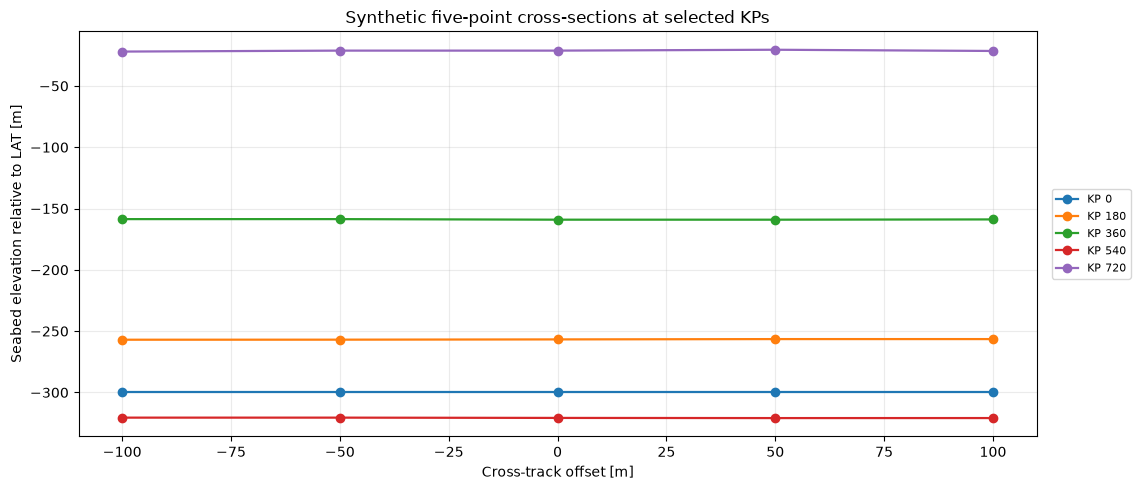

,engineering_kp_km,point_role,offset_m,utm32_easting_m_wgs84,utm32_northing_m_wgs84,seabed_elevation_m_lat
0,0.0,left_outer,-100.0,396653.527,7222115.049,-300.000
1,0.0,left_inner,-50.0,396603.354,7222115.905,-300.000
2,0.0,centreline,0.0,396553.180,7222116.761,-300.000
3,0.0,right_inner,50.0,396503.007,7222117.617,-300.000
4,0.0,right_outer,100.0,396452.833,7222118.473,-300.000
180,180.0,left_outer,-100.0,351530.775,7057537.973,-257.000
181,180.0,left_inner,-50.0,351483.866,7057555.787,-256.958
182,180.0,centreline,0.0,351436.957,7057573.602,-256.743
183,180.0,right_inner,50.0,351390.047,7057591.416,-256.484
184,180.0,right_outer,100.0,351343.138,7057609.231,-256.484


In [6]:
selected_kps = [0.0, 180.0, 360.0, 540.0, 720.0]
figure, axis = plt.subplots(figsize=(11.5, 5.0))
for kp_value in selected_kps:
    section = cross_df.loc[
        np.isclose(cross_df["engineering_kp_km"], kp_value)
    ].sort_values("offset_m")
    axis.plot(
        section["offset_m"],
        section["seabed_elevation_m_lat"],
        marker="o",
        linewidth=1.6,
        label=f"KP {kp_value:.0f}",
    )
axis.set_title("Synthetic five-point cross-sections at selected KPs")
axis.set_xlabel("Cross-track offset [m]")
axis.set_ylabel("Seabed elevation relative to LAT [m]")
axis.grid(alpha=0.25)
axis.legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
)
figure.tight_layout()
plt.show()

display(
    cross_df.loc[
        cross_df["engineering_kp_km"].isin(selected_kps),
        [
            "engineering_kp_km",
            "point_role",
            "offset_m",
            "utm32_easting_m_wgs84",
            "utm32_northing_m_wgs84",
            "seabed_elevation_m_lat",
        ],
    ].round(3)
)


## Simplified terrain-following NeqSim model

The centerline elevation change enters each 5 km segment. NeqSim calculates friction,
gravity, phase behavior, and heat transfer segment by segment. The outlet of one segment
is the inlet of the next—a hydraulic **daisy chain**.

The synthetic rich gas uses the SRK equation of state with the classic mixing rule.
The model specifies 180 bara, 10 °C, 40 MSm³/day, a 1.000 m assumed inside diameter,
0.045 mm roughness, constant 5 °C seawater, and an assumed overall heat-transfer
coefficient of 5 W/(m²·K). The public 42-inch value is an outside-size description;
it is not evidence for the assumed inside diameter.

For segment $j$, the geometry supplied to NeqSim is:

$$L_j=5000\ \mathrm{m},\qquad \Delta z_j=z_{j+1}-z_j$$

The overall checks are:

$$\Delta P=P_{in}-P_{out}$$

$$\varepsilon_m=\frac{\dot m_{out}-\dot m_{in}}{\dot m_{in}}$$


In [7]:
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)

INSIDE_DIAMETER_M = 1.000
ABSOLUTE_ROUGHNESS_M = 4.5e-5
INLET_PRESSURE_BARA = 180.0
INLET_TEMPERATURE_C = 10.0
SEAWATER_TEMPERATURE_C = 5.0
OVERALL_U_W_M2K = 5.0
BASE_FLOW_MSM3_DAY = 40.0
BASE_INCREMENTS = 5
COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.010,
    "methane": 0.820,
    "ethane": 0.080,
    "propane": 0.040,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "i-pentane": 0.005,
    "n-pentane": 0.005,
    "n-hexane": 0.005,
}


def create_inlet_stream(flow_msm3_day):
    assert math.isclose(sum(COMPOSITION.values()), 1.0, abs_tol=1.0e-12)
    fluid = SystemSrkEos(
        INLET_TEMPERATURE_C + 273.15,
        INLET_PRESSURE_BARA,
    )
    for component, mole_fraction in COMPOSITION.items():
        fluid.addComponent(component, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    stream = Stream(f"Åsgard inlet {flow_msm3_day:.1f}", fluid)
    stream.setFlowRate(flow_msm3_day, "MSm3/day")
    stream.setPressure(INLET_PRESSURE_BARA, "bara")
    stream.setTemperature(INLET_TEMPERATURE_C, "C")
    stream.run()
    return stream


def run_pipeline_case(flow_msm3_day, increments=BASE_INCREMENTS):
    terrain = profile_df.sort_values("engineering_kp_km").reset_index(
        drop=True
    )
    current_stream = create_inlet_stream(flow_msm3_day)
    inlet_mass_flow = current_stream.getFlowRate("kg/hr")
    rows = [
        {
            "engineering_kp_km": terrain.loc[0, "engineering_kp_km"],
            "pressure_bara": current_stream.getPressure("bara"),
            "temperature_c": current_stream.getTemperature("C"),
            "seabed_elevation_m_lat": terrain.loc[
                0,
                "seabed_elevation_m_lat",
            ],
            "liquid_holdup_fraction": 0.0,
            "flow_regime": "inlet",
        }
    ]
    for index in range(len(terrain) - 1):
        upstream = terrain.iloc[index]
        downstream = terrain.iloc[index + 1]
        segment_length_m = (
            downstream["engineering_kp_km"]
            - upstream["engineering_kp_km"]
        ) * 1000.0
        elevation_change_m = (
            downstream["seabed_elevation_m_lat"]
            - upstream["seabed_elevation_m_lat"]
        )
        pipe = PipeBeggsAndBrills(
            (
                f"Åsgard KP {upstream['engineering_kp_km']:.0f}-"
                f"{downstream['engineering_kp_km']:.0f}"
            ),
            current_stream,
        )
        pipe.setDiameter(INSIDE_DIAMETER_M)
        pipe.setPipeWallRoughness(ABSOLUTE_ROUGHNESS_M)
        pipe.setLength(segment_length_m)
        pipe.setElevation(elevation_change_m)
        pipe.setNumberOfIncrements(increments)
        pipe.setConstantSurfaceTemperature(SEAWATER_TEMPERATURE_C, "C")
        pipe.setHeatTransferCoefficient(OVERALL_U_W_M2K)
        pipe.run()
        current_stream = pipe.getOutletStream()
        rows.append(
            {
                "engineering_kp_km": downstream[
                    "engineering_kp_km"
                ],
                "pressure_bara": current_stream.getPressure("bara"),
                "temperature_c": current_stream.getTemperature("C"),
                "seabed_elevation_m_lat": downstream[
                    "seabed_elevation_m_lat"
                ],
                "liquid_holdup_fraction": float(pipe.getLiquidHoldup()),
                "flow_regime": str(pipe.getFlowRegime()),
            }
        )
    result_profile = pd.DataFrame(rows)
    outlet_mass_flow = current_stream.getFlowRate("kg/hr")
    summary = {
        "flow_msm3_day": flow_msm3_day,
        "increments_per_5_km": increments,
        "outlet_pressure_bara": current_stream.getPressure("bara"),
        "pressure_drop_bar": (
            INLET_PRESSURE_BARA - current_stream.getPressure("bara")
        ),
        "outlet_temperature_c": current_stream.getTemperature("C"),
        "mass_balance_relative_error": (
            (outlet_mass_flow - inlet_mass_flow) / inlet_mass_flow
        ),
        "maximum_liquid_holdup": result_profile[
            "liquid_holdup_fraction"
        ].max(),
        "segment_count": len(terrain) - 1,
    }
    return summary, result_profile


assumptions = pd.DataFrame(
    {
        "parameter": [
            "EOS / mixing rule",
            "Inlet pressure",
            "Inlet / seawater temperature",
            "Standard flow",
            "Assumed inside diameter",
            "Absolute roughness",
            "Overall U-value",
            "Terrain mesh",
        ],
        "value": [
            "SRK / classic",
            "180 bara",
            "10 / 5 °C",
            "40 MSm³/day",
            "1.000 m",
            "0.045 mm",
            "5 W/(m²·K)",
            "144 × 5 km",
        ],
        "status": [
            "model choice",
            "synthetic",
            "synthetic / reasonable deepwater boundary",
            "synthetic",
            "synthetic",
            "synthetic",
            "synthetic",
            "derived from open route/profile",
        ],
    }
)
display(assumptions)
print("Composition sum:", sum(COMPOSITION.values()))


Composition sum: 1.0


,parameter,value,status
0,EOS / mixing rule,SRK / classic,model choice
1,Inlet pressure,180 bara,synthetic
2,Inlet / seawater temperature,10 / 5 °C,synthetic / reasonable deepwater boundary
3,Standard flow,40 MSm³/day,synthetic
4,Assumed inside diameter,1.000 m,synthetic
5,Absolute roughness,0.045 mm,synthetic
6,Overall U-value,5 W/(m²·K),synthetic
7,Terrain mesh,144 × 5 km,derived from open route/profile


In [8]:
base_summary, base_profile = run_pipeline_case(BASE_FLOW_MSM3_DAY)
display(pd.Series(base_summary, name="base case").to_frame())
display(
    base_profile.loc[
        base_profile.index % 24 == 0,
        [
            "engineering_kp_km",
            "pressure_bara",
            "temperature_c",
            "seabed_elevation_m_lat",
            "flow_regime",
        ],
    ].round(3)
)


,base case
flow_msm3_day,40.000000
increments_per_5_km,5.000000
outlet_pressure_bara,128.347438
pressure_drop_bar,51.652562
outlet_temperature_c,2.351599
mass_balance_relative_error,0.000000
maximum_liquid_holdup,0.000000
segment_count,144.000000


,engineering_kp_km,pressure_bara,temperature_c,seabed_elevation_m_lat,flow_regime
0,0.0,180.000,10.000,-300.000,inlet
24,120.0,173.935,5.978,-348.720,SINGLE_PHASE
48,240.0,162.703,4.334,-174.068,SINGLE_PHASE
72,360.0,154.821,4.044,-159.090,SINGLE_PHASE
96,480.0,151.519,4.386,-369.330,SINGLE_PHASE
120,600.0,142.007,3.672,-295.151,SINGLE_PHASE
144,720.0,128.347,2.352,-21.200,SINGLE_PHASE


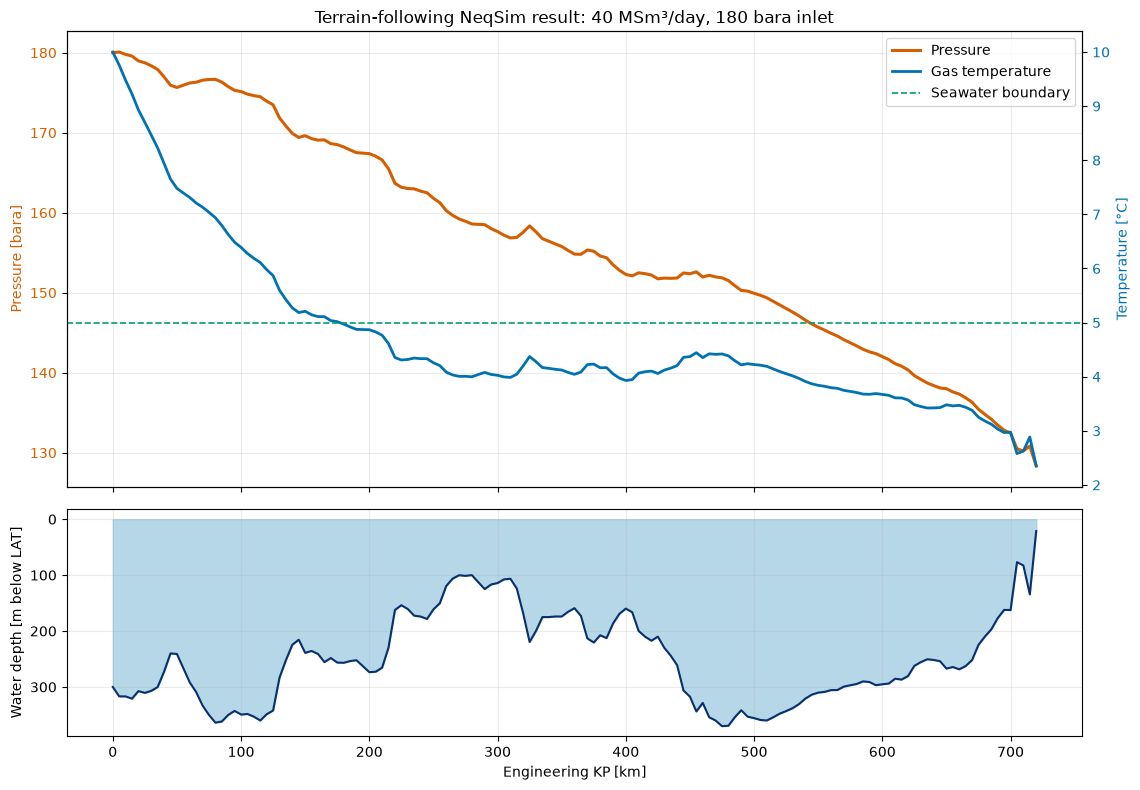

In [9]:
figure, (profile_axis, terrain_axis) = plt.subplots(
    2,
    1,
    figsize=(11.5, 8.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)
temperature_axis = profile_axis.twinx()
profile_axis.plot(
    base_profile["engineering_kp_km"],
    base_profile["pressure_bara"],
    color="#D55E00",
    linewidth=2.2,
    label="Pressure",
)
temperature_axis.plot(
    base_profile["engineering_kp_km"],
    base_profile["temperature_c"],
    color="#0072B2",
    linewidth=2.0,
    label="Gas temperature",
)
temperature_axis.axhline(
    SEAWATER_TEMPERATURE_C,
    color="#009E73",
    linestyle="--",
    linewidth=1.2,
    label="Seawater boundary",
)
profile_axis.set_ylabel("Pressure [bara]", color="#D55E00")
temperature_axis.set_ylabel("Temperature [°C]", color="#0072B2")
profile_axis.tick_params(axis="y", labelcolor="#D55E00")
temperature_axis.tick_params(axis="y", labelcolor="#0072B2")
profile_axis.grid(alpha=0.25)
profile_axis.set_title(
    "Terrain-following NeqSim result: 40 MSm³/day, 180 bara inlet"
)
lines_a, labels_a = profile_axis.get_legend_handles_labels()
lines_b, labels_b = temperature_axis.get_legend_handles_labels()
profile_axis.legend(lines_a + lines_b, labels_a + labels_b, loc="best")

terrain_axis.fill_between(
    base_profile["engineering_kp_km"],
    0.0,
    -base_profile["seabed_elevation_m_lat"],
    color="#9ECAE1",
    alpha=0.75,
)
terrain_axis.plot(
    base_profile["engineering_kp_km"],
    -base_profile["seabed_elevation_m_lat"],
    color="#08306B",
    linewidth=1.5,
)
terrain_axis.invert_yaxis()
terrain_axis.set_xlabel("Engineering KP [km]")
terrain_axis.set_ylabel("Water depth [m below LAT]")
terrain_axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()


## Flow sensitivity and numerical refinement

The 36 and 44 MSm³/day cases test the expected hydraulic trend around the base case.
A full 10-increment-per-segment repeat checks sensitivity to the internal axial
discretization. Conservation, positive pressure, liquid holdup, and trend assertions
are evaluated from the newly calculated results—not copied reference values.


5 → 10 increments: outlet pressure change 0.0013 bar
5 → 10 increments: outlet temperature change 0.0064 °C


,flow_msm3_day,outlet_pressure_bara,pressure_drop_bar,outlet_temperature_c,mass_balance_relative_error
0,36.0,137.616952,42.383048,3.080126,0.0
1,40.0,128.347438,51.652562,2.351599,0.0
2,44.0,117.487032,62.512968,1.214746,0.0


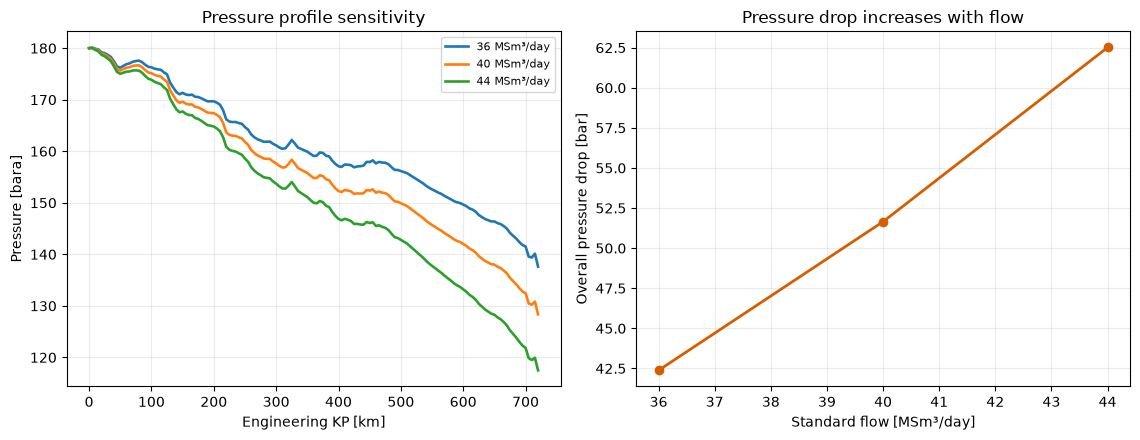

In [10]:
sensitivity_rows = []
profiles_by_flow = {BASE_FLOW_MSM3_DAY: base_profile}
for flow_msm3_day in [36.0, 40.0, 44.0]:
    if math.isclose(flow_msm3_day, BASE_FLOW_MSM3_DAY):
        case_summary = dict(base_summary)
    else:
        case_summary, case_profile = run_pipeline_case(flow_msm3_day)
        profiles_by_flow[flow_msm3_day] = case_profile
    sensitivity_rows.append(case_summary)

sensitivity_df = pd.DataFrame(sensitivity_rows)
refined_summary, refined_profile = run_pipeline_case(
    BASE_FLOW_MSM3_DAY,
    increments=10,
)
pressure_refinement_bar = abs(
    refined_summary["outlet_pressure_bara"]
    - base_summary["outlet_pressure_bara"]
)
temperature_refinement_c = abs(
    refined_summary["outlet_temperature_c"]
    - base_summary["outlet_temperature_c"]
)

display(
    sensitivity_df[
        [
            "flow_msm3_day",
            "outlet_pressure_bara",
            "pressure_drop_bar",
            "outlet_temperature_c",
            "mass_balance_relative_error",
        ]
    ].round(6)
)
print(
    "5 → 10 increments: outlet pressure change "
    f"{pressure_refinement_bar:.4f} bar"
)
print(
    "5 → 10 increments: outlet temperature change "
    f"{temperature_refinement_c:.4f} °C"
)

figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
for flow_msm3_day in sorted(profiles_by_flow):
    result_profile = profiles_by_flow[flow_msm3_day]
    axes[0].plot(
        result_profile["engineering_kp_km"],
        result_profile["pressure_bara"],
        linewidth=1.9,
        label=f"{flow_msm3_day:.0f} MSm³/day",
    )
axes[0].set_title("Pressure profile sensitivity")
axes[0].set_xlabel("Engineering KP [km]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(
    sensitivity_df["flow_msm3_day"],
    sensitivity_df["pressure_drop_bar"],
    marker="o",
    color="#D55E00",
    linewidth=2.0,
)
axes[1].set_title("Pressure drop increases with flow")
axes[1].set_xlabel("Standard flow [MSm³/day]")
axes[1].set_ylabel("Overall pressure drop [bar]")
axes[1].grid(alpha=0.25)
figure.tight_layout()
plt.show()


In [11]:
pressure_drops = sensitivity_df["pressure_drop_bar"].to_numpy()
validation = {
    "composition sums to one": math.isclose(
        sum(COMPOSITION.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "route ends at engineering KP 720 km": math.isclose(
        route_df["engineering_kp_km"].iloc[-1],
        720.0,
        abs_tol=1.0e-9,
    ),
    "145 stations and 725 cross-section points": (
        len(route_df) == 145 and len(cross_df) == 725
    ),
    "SODIR maximum depth is reproduced approximately": (
        abs(
            profile_df["water_depth_m_lat"].max()
            - metadata["sodir_reported_maximum_water_depth_m"]
        )
        < 5.0
    ),
    "base-case mass balance": (
        abs(base_summary["mass_balance_relative_error"]) < 1.0e-10
    ),
    "positive outlet pressure": base_summary["outlet_pressure_bara"] > 0.0,
    "pressure drop increases with flow": bool(
        np.all(np.diff(pressure_drops) > 0.0)
    ),
    "no modeled free liquid": (
        base_summary["maximum_liquid_holdup"] < 1.0e-12
    ),
    "refinement pressure difference below 0.01 bar": (
        pressure_refinement_bar < 0.01
    ),
    "refinement temperature difference below 0.02 °C": (
        temperature_refinement_c < 0.02
    ),
    "exact source class-location guard": loaded_path == NEQSIM_JAR.resolve(),
}
validation_df = pd.DataFrame(
    {
        "check": list(validation),
        "passed": list(validation.values()),
    }
)
display(validation_df)
assert validation_df["passed"].all()
print(f"All {len(validation_df)} engineering and provenance checks passed.")


All 11 engineering and provenance checks passed.


,check,passed
0,composition sums to one,True
1,route ends at engineering KP 720 km,True
2,145 stations and 725 cross-section points,True
3,SODIR maximum depth is reproduced approximately,True
4,base-case mass balance,True
5,positive outlet pressure,True
6,pressure drop increases with flow,True
7,no modeled free liquid,True
8,refinement pressure difference below 0.01 bar,True
9,refinement temperature difference below 0.02 °C,True


## Results, interpretation, and limitations

The clean run calculates the full pressure and temperature profiles using the embedded
open-data terrain. Pressure drop rises monotonically with flow and total mass flow is
conserved. The gas may cool below the 5 °C seawater boundary because Joule–Thomson
cooling competes with heat transfer from the sea; this does not imply a colder seawater
assumption.

Evidence reaches **level 3** of the NeqSim evidence ladder: public-source reconciliation,
conservation, numerical refinement, and qualitative sensitivity trends. It is not a
calibration against operator measurements or an independent commercial simulator.

Key limitations:

- SODIR geometry is low resolution and generalized; public positional accuracy is not survey accuracy.
- EMODnet is regional bathymetry; burial, cover, trench depth, free spans, and as-laid KP are unavailable.
- The 720 km KP scale reconciles to Gassco's published length rather than measured pipe joints.
- The `.C5P` export is synthetic and not verified against a proprietary importer specification.
- Fluid, wall thickness/inside diameter, roughness, flow, inlet state, U-value, and seawater temperature are assumptions.
- The model excludes linepack, compressor/control dynamics, side streams, capacity, hydrate/wax/corrosion, and integrity calculations.

For finite-duration composition and flow events, continue with
[Dynamic CO₂ and flow tracing](asgard_transport_dynamic_co2_tracing.ipynb).

### Suggested exercises

1. Set `REFRESH_OPEN_DATA = True` and compare source hashes and bathymetry changes.
2. Replace the constant seawater temperature with a documented seasonal profile.
3. Sweep inside diameter and U-value, keeping assumed and observed inputs visually distinct.
4. Add hydrate-margin calculations without treating this screening fluid as asset PVT.
5. Compare terrain-following and flat-pipe pressure profiles to isolate elevation effects.

Documentation impact: this notebook adds a new open-data route-to-simulation example and
catalog entry. It does not change NeqSim Java/Python APIs or numerical behavior. No
actionable NeqSim library defect was found; the unavailable proprietary C5P specification
is an external data-format limitation rather than a NeqSim issue.
